=== VISUALISATION Q-LEARNING ===


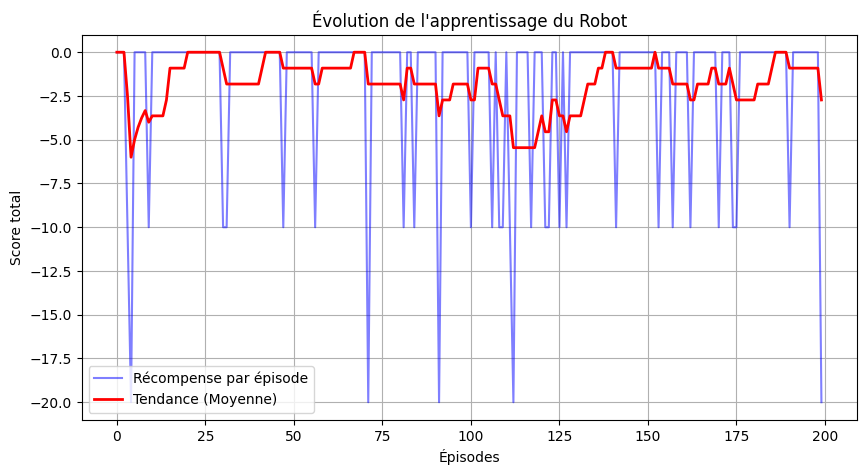

In [2]:
import random
import matplotlib.pyplot as plt

# =========================================================
# 1. LOGIQUE Q-LEARNING
# =========================================================

def entrainer_agent_avec_stats(nb_episodes=200):
    q_table = [[0.0, 0.0] for _ in range(4)]
    stats_recompenses = [] # Pour stocker les scores de chaque essai

    alpha, gamma, epsilon = 0.1, 0.9, 0.2

    for _ in range(nb_episodes):
        etat = 0
        total_recompense_episode = 0

        while etat != 3:
            # Choix de l'action
            action = random.randint(0, 1) if random.random() < epsilon else (0 if q_table[etat][0] > q_table[etat][1] else 1)

            nouveau_etat = max(0, min(3, etat + (1 if action == 1 else -1)))
            recompense = 10 if nouveau_etat == 3 else (-10 if nouveau_etat == 1 else 0)

            # Mise à jour Q-Table
            q_table[etat][action] += alpha * (recompense + gamma * max(q_table[nouveau_etat]) - q_table[etat][action])

            total_recompense_episode += recompense
            etat = nouveau_etat

        stats_recompenses.append(total_recompense_episode)

    return q_table, stats_recompenses

# =========================================================
# 2.                        TEST
# =========================================================

q_final, historique = entrainer_agent_avec_stats(200)

print("=== VISUALISATION Q-LEARNING ===")
plt.figure(figsize=(10, 5))
plt.plot(historique, color='blue', alpha=0.5, label='Récompense par épisode')
# Calcul d'une moyenne mobile pour voir la tendance
moyenne_mobile = [sum(historique[max(0, i-10):i+1]) / len(historique[max(0, i-10):i+1]) for i in range(len(historique))]
plt.plot(moyenne_mobile, color='red', linewidth=2, label='Tendance (Moyenne)')
plt.title("Évolution de l'apprentissage du Robot")
plt.xlabel("Épisodes")
plt.ylabel("Score total")
plt.legend()
plt.grid(True)
plt.show()

=== VISUALISATION PCA ===


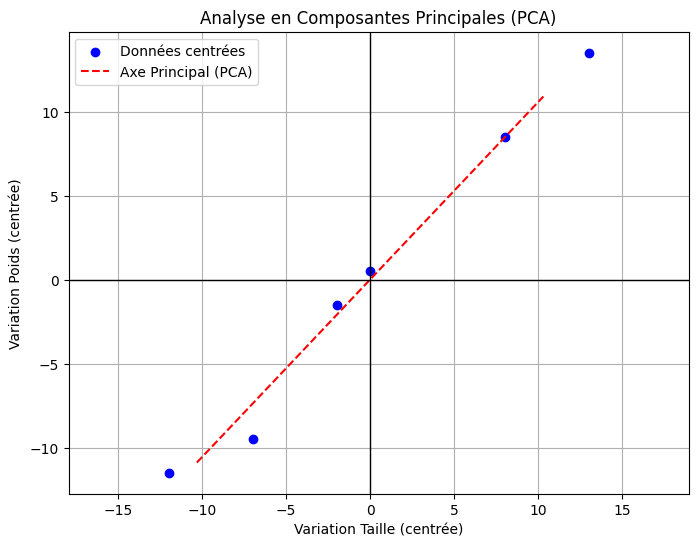

In [4]:
import math
import matplotlib.pyplot as plt

# =========================================================
# 1. LOGIQUE PCA
# =========================================================

def calculer_pca_complet(X):
    nb_lignes, nb_cols = len(X), len(X[0])
    moyennes = [sum(ligne[j] for ligne in X) / nb_lignes for j in range(nb_cols)]
    X_c = [[ligne[j] - moyennes[j] for j in range(nb_cols)] for ligne in X]

    # Méthode des puissances pour le vecteur principal
    v = [1.0] * nb_cols
    for _ in range(20):
        nouveau_v = [0.0] * nb_cols
        for ligne in X_c:
            score = sum(ligne[j] * v[j] for j in range(nb_cols))
            for j in range(nb_cols): nouveau_v[j] += score * ligne[j]
        norme = math.sqrt(sum(x**2 for x in nouveau_v))
        v = [x / norme for x in nouveau_v]

    return X_c, v, moyennes

# =========================================================
#                           TEST
# =========================================================

X_data = [[170, 70], [172, 72], [180, 80], [160, 60], [165, 62], [185, 85]]
X_centres, vecteur, moyennes = calculer_pca_complet(X_data)

print("=== VISUALISATION PCA ===")
plt.figure(figsize=(8, 6))

# 1. Affichage des points centrés
x_pts = [p[0] for p in X_centres]
y_pts = [p[1] for p in X_centres]
plt.scatter(x_pts, y_pts, color='blue', label='Données centrées')

# 2. Affichage de l'axe principal (Composante 1)
# On trace une ligne qui suit la direction du vecteur
x_axe = [-vecteur[0]*15, vecteur[0]*15]
y_axe = [-vecteur[1]*15, vecteur[1]*15]
plt.plot(x_axe, y_axe, color='red', linestyle='--', label='Axe Principal (PCA)')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title("Analyse en Composantes Principales (PCA)")
plt.xlabel("Variation Taille (centrée)")
plt.ylabel("Variation Poids (centrée)")
plt.legend()
plt.axis('equal') # Pour garder les proportions
plt.grid(True)
plt.show()